In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score,
    f1_score, accuracy_score,
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

from features import build_hunting_features, build_rut_features
from grid import create_grid, spatial_join_points_to_grid
from infrastructure import (
    build_road_features,
    load_roads_for_study_area,
    build_linear_features,
    load_linear_layer_for_study_area,
    build_speedlimit_features,
)
from weather import build_cell_month_temperature, build_cell_month_precipitation


In [2]:
FIG_DIR = Path("data/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({
    # Backgrounds
    "figure.facecolor": "white",
    "axes.facecolor": "white",

    # Text colors
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",

    # Grid (optional, subtle)
    "grid.color": "grey",

    # Figure quality
    "figure.dpi": 300,
    "savefig.dpi": 300,

    # Font sizes (nice for thesis)
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,


})

In [3]:
def load_collision_data(path: str) -> gpd.GeoDataFrame:
    df = pd.read_csv(path, sep=";", encoding="latin1", low_memory=False)

    df = df.rename(columns={
        "Datum":       "datetime",
        "Viltslag":    "species",
        "Län":         "lan",
        "Kommun":      "kommun",
        "Lat WGS84":   "lat",
        "Long WGS84":  "lon",
    })

    # Parse coordinates (Swedish decimal-comma → dot)
    for col in ("lat", "lon"):
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(",", ".", regex=False),
            errors="coerce",
        )

    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce", dayfirst=False)
    df = df.dropna(subset=["datetime", "lat", "lon"])

    # Keep only plausible Sweden WGS84 bounding box
    df = df[df["lat"].between(55, 70) & df["lon"].between(10, 25)]

    return gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326",
    ).to_crs("EPSG:3006")


def load_collision_data_multi_year(folder_path: str) -> gpd.GeoDataFrame:
    folder = Path(folder_path)
    files  = sorted(folder.glob("*.csv"))
    if not files:
        raise ValueError("No CSV files found in folder")
    print(f"Found {len(files)} files")
    gdfs = [load_collision_data(str(f)) for f in files]
    gdf  = pd.concat(gdfs, ignore_index=True)
    print("Combined shape:", gdf.shape)
    return gdf


DATA_DIR = "C:/Users/Amanda/PycharmProjects/thesis_boogaloo/data"

# Single load — everything downstream uses `gdf`
gdf = load_collision_data_multi_year(f"{DATA_DIR}/Collisions")
gdf = gdf[gdf["datetime"].dt.year <= 2025]



Found 12 files
Combined shape: (732678, 16)


In [4]:
def build_cell_month_table_full(gdf_points, cell_size=10000):
    grid   = create_grid(gdf_points, cell_size=cell_size)
    joined = spatial_join_points_to_grid(gdf_points, grid)
    joined = joined.dropna(subset=["cell_id"])
    joined["cell_id"]      = joined["cell_id"].astype(int)
    joined["period_start"] = joined["datetime"].dt.to_period("M").dt.to_timestamp()

    observed = (
        joined.groupby(["cell_id", "period_start"])
        .size()
        .reset_index(name="collision_count")
    )


    # Full month range
    periods    = gdf_points["datetime"].dt.to_period("M")
    min_month  = periods.min().to_timestamp()
    max_month  = periods.max().to_timestamp()
    all_months = pd.date_range(start=min_month, end=max_month, freq="MS")


    full_index = pd.MultiIndex.from_product(
        [grid["cell_id"].astype(int).unique(), all_months],
        names=["cell_id", "period_start"],
    )
    cell_month = (
        full_index.to_frame(index=False)
        .merge(observed, on=["cell_id", "period_start"], how="left")
    )
    cell_month["collision_count"] = cell_month["collision_count"].fillna(0).astype(int)

    # High-risk label: top 25 % of non-zero months
    nonzero = cell_month.loc[cell_month["collision_count"] > 0, "collision_count"]
    if nonzero.empty:
        raise ValueError("No non-zero collision counts; cannot define risk threshold.")
    threshold = nonzero.quantile(0.75)
    cell_month["risk"] = (cell_month["collision_count"] >= threshold).astype(int)


    return grid, joined, cell_month


grid, joined, cell_month = build_cell_month_table_full(gdf, cell_size=10000)


In [5]:
SPECIES_MAP = {
    "älg":      "moose",
    "rådjur":   "roe_deer",
    "vildsvin": "wild_boar",
    "dovhjort": "fallow_deer",
}

daylight_df = gdf[gdf["datetime"].dt.year <= 2025].copy()
daylight_df["species"] = (
    daylight_df["species"].astype(str).str.strip().str.lower().replace(SPECIES_MAP)
)
daylight_df["hour"]  = daylight_df["datetime"].dt.hour
daylight_df["month"] = daylight_df["datetime"].dt.month


def vectorised_light_condition(df: pd.DataFrame) -> pd.Series:
    h, m = df["hour"], df["month"]
    winter = m.isin([12, 1, 2])
    summer = m.isin([6, 7, 8])
    spring_autumn = ~(winter | summer)

    conditions = [
        winter & h.between(9, 14),
        winter & h.between(7, 8),
        winter & h.between(15, 16),
        summer & h.between(5, 20),
        summer & h.between(3, 4),
        summer & h.between(21, 22),
        spring_autumn & h.between(7, 17),
        spring_autumn & h.between(5, 6),
        spring_autumn & h.between(18, 19),
    ]
    choices = ["day", "dawn", "dusk", "day", "dawn", "dusk", "day", "dawn", "dusk"]
    return np.select(conditions, choices, default="night")


daylight_df["light_condition"] = vectorised_light_condition(daylight_df)




In [6]:
light_counts = (
    daylight_df["light_condition"]
    .value_counts()
    .rename_axis("light_condition")
    .reset_index(name="collision_count")
)
light_counts["share"] = light_counts["collision_count"] / light_counts["collision_count"].sum()
print(light_counts)

species_light = (
    daylight_df.groupby(["species", "light_condition"])
    .size()
    .reset_index(name="collision_count")
)
species_totals = (
    species_light.groupby("species")["collision_count"]
    .sum()
    .rename("species_total")
    .reset_index()
)
species_light = species_light.merge(species_totals, on="species", how="left")
species_light["share_within_species"] = (
    species_light["collision_count"] / species_light["species_total"]
)


  light_condition  collision_count     share
0           night           302400  0.424414
1             day           226965  0.318542
2            dusk            98855  0.138742
3            dawn            84292  0.118303


In [7]:
SEASON_MAP = {
    12: "winter", 1: "winter",  2: "winter",
    3:  "spring", 4: "spring",  5: "spring",
    6:  "summer", 7: "summer",  8: "summer",
    9:  "autumn", 10: "autumn", 11: "autumn",
}
daylight_df["season"] = daylight_df["month"].map(SEASON_MAP)

season_light = (
    daylight_df.groupby(["season", "light_condition"])
    .size()
    .reset_index(name="collision_count")
)


In [8]:
def build_lagged_light(joined: gpd.GeoDataFrame) -> pd.DataFrame:
    df = joined[["cell_id", "datetime"]].copy()
    df["cell_id"]      = df["cell_id"].astype(int)
    df["period_start"] = df["datetime"].dt.to_period("M").dt.to_timestamp()
    df["hour"]         = df["datetime"].dt.hour

    # Simplified (time-of-day only) light classification for cell-month features
    conditions = [
        df["hour"].between(5, 7),
        df["hour"].between(8, 16),
        df["hour"].between(17, 20),
    ]
    df["light_condition"] = np.select(conditions, ["dawn", "day", "dusk"], default="night")

    light_counts = (
        df.groupby(["cell_id", "period_start", "light_condition"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )

    light_cols = [c for c in light_counts.columns if c not in ["cell_id", "period_start"]]
    row_sums   = light_counts[light_cols].sum(axis=1)
    light_counts[light_cols] = light_counts[light_cols].div(row_sums.where(row_sums > 0, 1), axis=0)

    light_counts = light_counts.sort_values(["cell_id", "period_start"])
    for col in light_cols:
        light_counts[f"{col}_lag1"] = light_counts.groupby("cell_id")[col].shift(1)

    lag_cols = [f"{c}_lag1" for c in light_cols]
    return light_counts[["cell_id", "period_start"] + lag_cols].fillna(0)


lagged_light = build_lagged_light(joined)


In [9]:

SPECIES_LIST = ["roe_deer", "moose", "wild_boar", "fallow_deer"]


SPECIES_LABELS = {
    "roe_deer": "Roe deer",
    "moose": "Moose",
    "wild_boar": "Wild boar",
    "fallow_deer": "Fallow deer",
}

BASE_FEATURES = [
    "nearest_road_distance_m",
    "fence_density",
    "fence_near_10km",
    "temp_mean",
    "temp_min",
    "temp_max",
    "precip_total",
    "night_lag1",
    "dawn_lag1",
    "day_lag1",
    "dusk_lag1",
    "month_sin",
    "month_cos",
    "speedlimit_mean_weighted",
    "speedlimit_90plus_share",
]

SPECIES_FEATURES = {
    "roe_deer": [
        "roe_deer_lag1",
        "roe_deer_hunting_frac",
        "roe_deer_rut_frac",
    ],
    "moose": [
        "moose_lag1",
        "moose_hunting_frac",
        "moose_rut_frac",
    ],
    "wild_boar": [
        "wild_boar_lag1",
        "wild_boar_hunting_frac",
        "wild_boar_rut_frac",
    ],
    "fallow_deer": [
        "fallow_deer_lag1",
        "fallow_deer_hunting_frac",
        "fallow_deer_rut_frac",
    ],
}


In [10]:
def build_species_cell_month_table(joined, grid, species_name):
    df = joined.copy()

    df["species"] = (
        df["species"]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace(SPECIES_MAP)
    )

    df = df[df["species"] == species_name].copy()
    df["cell_id"] = df["cell_id"].astype(int)
    df["period_start"] = df["datetime"].dt.to_period("M").dt.to_timestamp()

    observed = (
        df.groupby(["cell_id", "period_start"])
        .size()
        .reset_index(name="collision_count")
    )

    all_months = pd.date_range(
        start=joined["datetime"].dt.to_period("M").min().to_timestamp(),
        end=joined["datetime"].dt.to_period("M").max().to_timestamp(),
        freq="MS"
    )

    full_index = pd.MultiIndex.from_product(
        [grid["cell_id"].astype(int).unique(), all_months],
        names=["cell_id", "period_start"]
    )

    cell_month_species = (
        full_index.to_frame(index=False)
        .merge(observed, on=["cell_id", "period_start"], how="left")
    )

    cell_month_species["collision_count"] = (
        cell_month_species["collision_count"]
        .fillna(0)
        .astype(int)
    )

    nonzero = cell_month_species.loc[
        cell_month_species["collision_count"] > 0,
        "collision_count"
    ]

    if nonzero.empty:
        raise ValueError(f"No non-zero collisions for {species_name}")

    threshold = nonzero.quantile(0.75)

    cell_month_species["risk"] = (
            cell_month_species["collision_count"] >= threshold
    ).astype(int)

    print(f"\n{species_name}")
    print("Threshold:", threshold)
    print(cell_month_species["risk"].value_counts())

    return cell_month_species

In [11]:
def build_lagged_species_all(joined):
    relevant = ["moose", "roe_deer", "wild_boar", "fallow_deer"]

    df = joined[["cell_id", "datetime", "species"]].copy()
    df["cell_id"] = df["cell_id"].astype(int)
    df["period_start"] = df["datetime"].dt.to_period("M").dt.to_timestamp()
    df["species"] = (
        df["species"]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace(SPECIES_MAP)
    )

    df = df[df["species"].isin(relevant)].copy()

    species_counts = (
        df.groupby(["cell_id", "period_start", "species"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
        .sort_values(["cell_id", "period_start"])
    )

    for species in relevant:
        if species not in species_counts.columns:
            species_counts[species] = 0

    for species in relevant:
        species_counts[f"{species}_lag1"] = (
            species_counts.groupby("cell_id")[species].shift(1)
        )

    lag_cols = [f"{s}_lag1" for s in relevant]

    return species_counts[["cell_id", "period_start"] + lag_cols].fillna(0)


lagged_species = build_lagged_species_all(joined)

In [12]:
# Build shared infrastructure features ONCE

roads = load_roads_for_study_area(
    path=f"{DATA_DIR}/Sverige_Vägtrafiknät_GeoPackage/Sverige_Vägtrafiknät_194602.gpkg",
    gdf_points=gdf,
    buffer_m=2000,
)

road_features = build_road_features(
    grid=grid,
    roads=roads,
    keep_only_classes=["bilnät"],
)

railways = load_linear_layer_for_study_area(
    path=f"{DATA_DIR}/Järnvägnät_grundegenskaper/Järnvägsnät_grundegenskaper3_0_GeoPackage.gpkg",
    gdf_points=gdf,
    buffer_m=2000,
)

rail_features = build_linear_features(
    grid=grid,
    lines=railways,
    prefix="rail"
)

fences = load_linear_layer_for_study_area(
    path=f"{DATA_DIR}/Barrairanalys/Barriaranalys.gpkg",
    gdf_points=gdf,
    buffer_m=2000,
    layer="barriarer_kvarvarande_vag",
)

fence_features = build_linear_features(
    grid=grid,
    lines=fences,
    prefix="fence"
)

speedlimit = load_linear_layer_for_study_area(
    path=f"{DATA_DIR}/Speedlimit/ISA.gpkg",
    gdf_points=gdf,
    buffer_m=2000,
)

speedlimit_features = build_speedlimit_features(
    grid=grid,
    speedlimit_gdf=speedlimit,
    speed_col="HTHAST",
)

In [13]:
road_cells = (
    road_features
    .query("road_length_m > 0")["cell_id"]
    .astype(int)
    .unique()
)

grid_small = grid[grid["cell_id"].isin(road_cells)].copy()

temperature_features = build_cell_month_temperature(grid=grid_small)
precip_features = build_cell_month_precipitation(grid=grid_small)

In [14]:
def build_species_model_df(species_name):
    df = build_species_cell_month_table(
        joined=joined,
        grid=grid,
        species_name=species_name,
    )

    df = (
        df.merge(road_features.drop(columns="geometry"), on="cell_id", how="left")
        .query("road_length_m > 0")
        .copy()
    )

    df = df.merge(
        rail_features.drop(columns=["geometry", "cell_area_m2"], errors="ignore"),
        on="cell_id",
        how="left",
    )

    for col in ["rail_length_m", "rail_density", "nearest_rail_distance_m"]:
        df[col] = df[col].fillna(0)

    df["rail_near_10km"] = (
            df["nearest_rail_distance_m"] < 10_000
    ).astype(int)

    df = df.merge(
        fence_features.drop(columns=["geometry", "cell_area_m2"], errors="ignore"),
        on="cell_id",
        how="left",
    )

    for col in ["fence_length_m", "fence_density", "nearest_fence_distance_m"]:
        df[col] = df[col].fillna(0)

    df["fence_near_10km"] = (
            df["nearest_fence_distance_m"] < 10_000
    ).astype(int)

    df = df.merge(
        speedlimit_features.drop(columns="geometry"),
        on="cell_id",
        how="left",
    )

    for col in [
        "speedlimit_mean_weighted",
        "speedlimit_max",
        "speedlimit_min",
        "speedlimit_90plus_share",
        "speedlimit_segment_length_m",
    ]:
        df[col] = df[col].fillna(0)

    df = df.merge(
        temperature_features[[
            "cell_id", "period_start",
            "temp_mean", "temp_min", "temp_max"
        ]],
        on=["cell_id", "period_start"],
        how="left",
    )

    df = df.merge(
        precip_features[[
            "cell_id", "period_start", "precip_total"
        ]],
        on=["cell_id", "period_start"],
        how="left",
    )

    df = df.merge(
        lagged_species,
        on=["cell_id", "period_start"],
        how="left",
    )

    for col in [
        "moose_lag1",
        "roe_deer_lag1",
        "wild_boar_lag1",
        "fallow_deer_lag1",
    ]:
        df[col] = df[col].fillna(0)

    df = df.merge(
        lagged_light,
        on=["cell_id", "period_start"],
        how="left",
    )

    light_lag_cols = [
        c for c in lagged_light.columns
        if c not in ["cell_id", "period_start"]
    ]

    for col in light_lag_cols:
        df[col] = df[col].fillna(0)

    df["month"] = df["period_start"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df = build_hunting_features(df)
    df = build_rut_features(df)

    df = df.dropna(
        subset=["temp_mean", "temp_min", "temp_max", "precip_total"]
    ).copy()

    return df

In [15]:
def make_expanding_time_splits(months, min_train_months=12, test_horizon=1):
    months = list(months)

    return [
        (months[:i], months[i:i + test_horizon])
        for i in range(min_train_months, len(months) - test_horizon + 1)
    ]

In [16]:
def evaluate_time_splits(model_df, features, target, splits):
    results = []
    oof_probs_rf = []
    oof_probs_lr = []
    oof_labels = []
    fold_importances = []

    for fold_idx, (train_months, test_months) in enumerate(splits, start=1):
        train = model_df[model_df["period_start"].isin(train_months)].copy()
        test = model_df[model_df["period_start"].isin(test_months)].copy()

        X_train, y_train = train[features], train[target]
        X_test, y_test = test[features], test[target]

        if len(test) == 0 or y_train.nunique() < 2 or y_test.nunique() < 2:
            continue

        logreg = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=3000, class_weight="balanced")),
        ])

        logreg.fit(X_train, y_train)
        y_pred_lr = logreg.predict(X_test)
        y_prob_lr = logreg.predict_proba(X_test)[:, 1]

        results.append({
            "fold": fold_idx,
            "model": "logreg",
            "auc": roc_auc_score(y_test, y_prob_lr),
            "precision": precision_score(y_test, y_pred_lr, zero_division=0),
            "recall": recall_score(y_test, y_pred_lr, zero_division=0),
            "f1": f1_score(y_test, y_pred_lr, zero_division=0),
            "accuracy": accuracy_score(y_test, y_pred_lr),
        })

        rf = RandomForestClassifier(
            n_estimators=100,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )

        rf.fit(X_train, y_train)
        y_pred_rf = rf.predict(X_test)
        y_prob_rf = rf.predict_proba(X_test)[:, 1]

        results.append({
            "fold": fold_idx,
            "model": "rf",
            "auc": roc_auc_score(y_test, y_prob_rf),
            "precision": precision_score(y_test, y_pred_rf, zero_division=0),
            "recall": recall_score(y_test, y_pred_rf, zero_division=0),
            "f1": f1_score(y_test, y_pred_rf, zero_division=0),
            "accuracy": accuracy_score(y_test, y_pred_rf),
        })

        oof_probs_lr.extend(y_prob_lr.tolist())
        oof_probs_rf.extend(y_prob_rf.tolist())
        oof_labels.extend(y_test.tolist())

        fold_importances.append(
            pd.Series(rf.feature_importances_, index=features)
        )

    results_df = pd.DataFrame(results)

    if fold_importances:
        mean_importance = (
            pd.concat(fold_importances, axis=1)
            .mean(axis=1)
            .sort_values(ascending=False)
        )
    else:
        mean_importance = pd.Series(dtype=float)

    return (
        results_df,
        np.array(oof_probs_rf),
        np.array(oof_probs_lr),
        np.array(oof_labels),
        mean_importance,
    )

In [24]:
OUTPUT_DIR = Path(f"{DATA_DIR}/processedtest")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

species_results = {}
species_importances = {}
comparison_rows = []

for species_name in SPECIES_LIST:
    print("\n" + "=" * 80)
    print(f"Running species-specific model: {species_name}")
    print("=" * 80)

    species_df = build_species_model_df(species_name)
    species_features = BASE_FEATURES + SPECIES_FEATURES[species_name]

    missing = [f for f in species_features if f not in species_df.columns]
    if missing:
        raise ValueError(f"Missing features for {species_name}: {missing}")

    species_df_clean = species_df.dropna(subset=species_features).copy()

    print("Clean shape:", species_df_clean.shape)
    print(species_df_clean["risk"].value_counts())

    species_df_clean["year"] = species_df_clean["period_start"].dt.year
    years = sorted(species_df_clean["year"].unique())

    splits = []

    for i in range(1, len(years)):
        train_years = years[:i]
        test_year = years[i]

        train_periods = sorted(
            species_df_clean.loc[
                species_df_clean["year"].isin(train_years),
                "period_start"
            ].unique()
        )

        test_periods = sorted(
            species_df_clean.loc[
                species_df_clean["year"] == test_year,
                "period_start"
            ].unique()
        )

        splits.append((train_periods, test_periods))

        train_df = species_df_clean[
            species_df_clean["period_start"].isin(train_periods)
        ]

        test_df = species_df_clean[
            species_df_clean["period_start"].isin(test_periods)
        ]

        print(
            f"Fold {i}: "
            f"train years={train_years}, "
            f"test year={test_year}, "
            f"train={len(train_df):,}, "
            f"test={len(test_df):,}, "
            f"test positives={test_df['risk'].sum():,}, "
            f"positive rate={test_df['risk'].mean():.4f}"
        )

    results_df, oof_probs_rf, oof_probs_lr, oof_labels, mean_importance = evaluate_time_splits(
        model_df=species_df_clean,
        features=species_features,
        target="risk",
        splits=splits,
    )

    summary = (
        results_df
        .groupby("model")[["auc", "precision", "recall", "f1", "accuracy"]]
        .agg(["mean", "std"])
        .round(3)
    )

    print(summary)
    print(mean_importance)

    species_results[species_name] = {
        "df": species_df_clean,
        "features": species_features,
        "results": results_df,
        "summary": summary,
        "oof_probs_rf": oof_probs_rf,
        "oof_probs_lr": oof_probs_lr,
        "oof_labels": oof_labels,
    }

    species_importances[species_name] = mean_importance

    for model_name in ["logreg", "rf"]:
        comparison_rows.append({
            "species": species_name,
            "model": model_name,
            "auc_mean": summary.loc[model_name, ("auc", "mean")],
            "auc_std": summary.loc[model_name, ("auc", "std")],
            "precision_mean": summary.loc[model_name, ("precision", "mean")],
            "precision_std": summary.loc[model_name, ("precision", "std")],
            "recall_mean": summary.loc[model_name, ("recall", "mean")],
            "recall_std": summary.loc[model_name, ("recall", "std")],
            "f1_mean": summary.loc[model_name, ("f1", "mean")],
            "f1_std": summary.loc[model_name, ("f1", "std")],
            "accuracy_mean": summary.loc[model_name, ("accuracy", "mean")],
            "accuracy_std": summary.loc[model_name, ("accuracy", "std")],
        })

    species_df_clean.to_csv(
        OUTPUT_DIR / f"model_df_clean_{species_name}.csv",
        index=False,
    )

    results_df.to_csv(
        OUTPUT_DIR / f"cv_results_{species_name}.csv",
        index=False,
    )

    mean_importance.to_csv(
        OUTPUT_DIR / f"feature_importance_{species_name}.csv",
    )

species_comparison = pd.DataFrame(comparison_rows)

species_comparison.to_csv(
    OUTPUT_DIR / "species_model_comparison.csv",
    index=False,
)

print(species_comparison)


Running species-specific model: roe_deer

roe_deer
Threshold: 4.0
risk
0    1328831
1      46477
Name: count, dtype: int64
Clean shape: (147828, 45)
risk
0    136427
1     11401
Name: count, dtype: int64
Fold 1: train years=[np.int32(2015)], test year=2016, train=13,428, test=13,428, test positives=919, positive rate=0.0684
Fold 2: train years=[np.int32(2015), np.int32(2016)], test year=2017, train=26,856, test=13,548, test positives=909, positive rate=0.0671
Fold 3: train years=[np.int32(2015), np.int32(2016), np.int32(2017)], test year=2018, train=40,404, test=13,428, test positives=1,046, positive rate=0.0779
Fold 4: train years=[np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018)], test year=2019, train=53,832, test=13,428, test positives=1,010, positive rate=0.0752
Fold 5: train years=[np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019)], test year=2020, train=67,260, test=13,428, test positives=977, positive rate=0.0728
Fold 6: train years=[

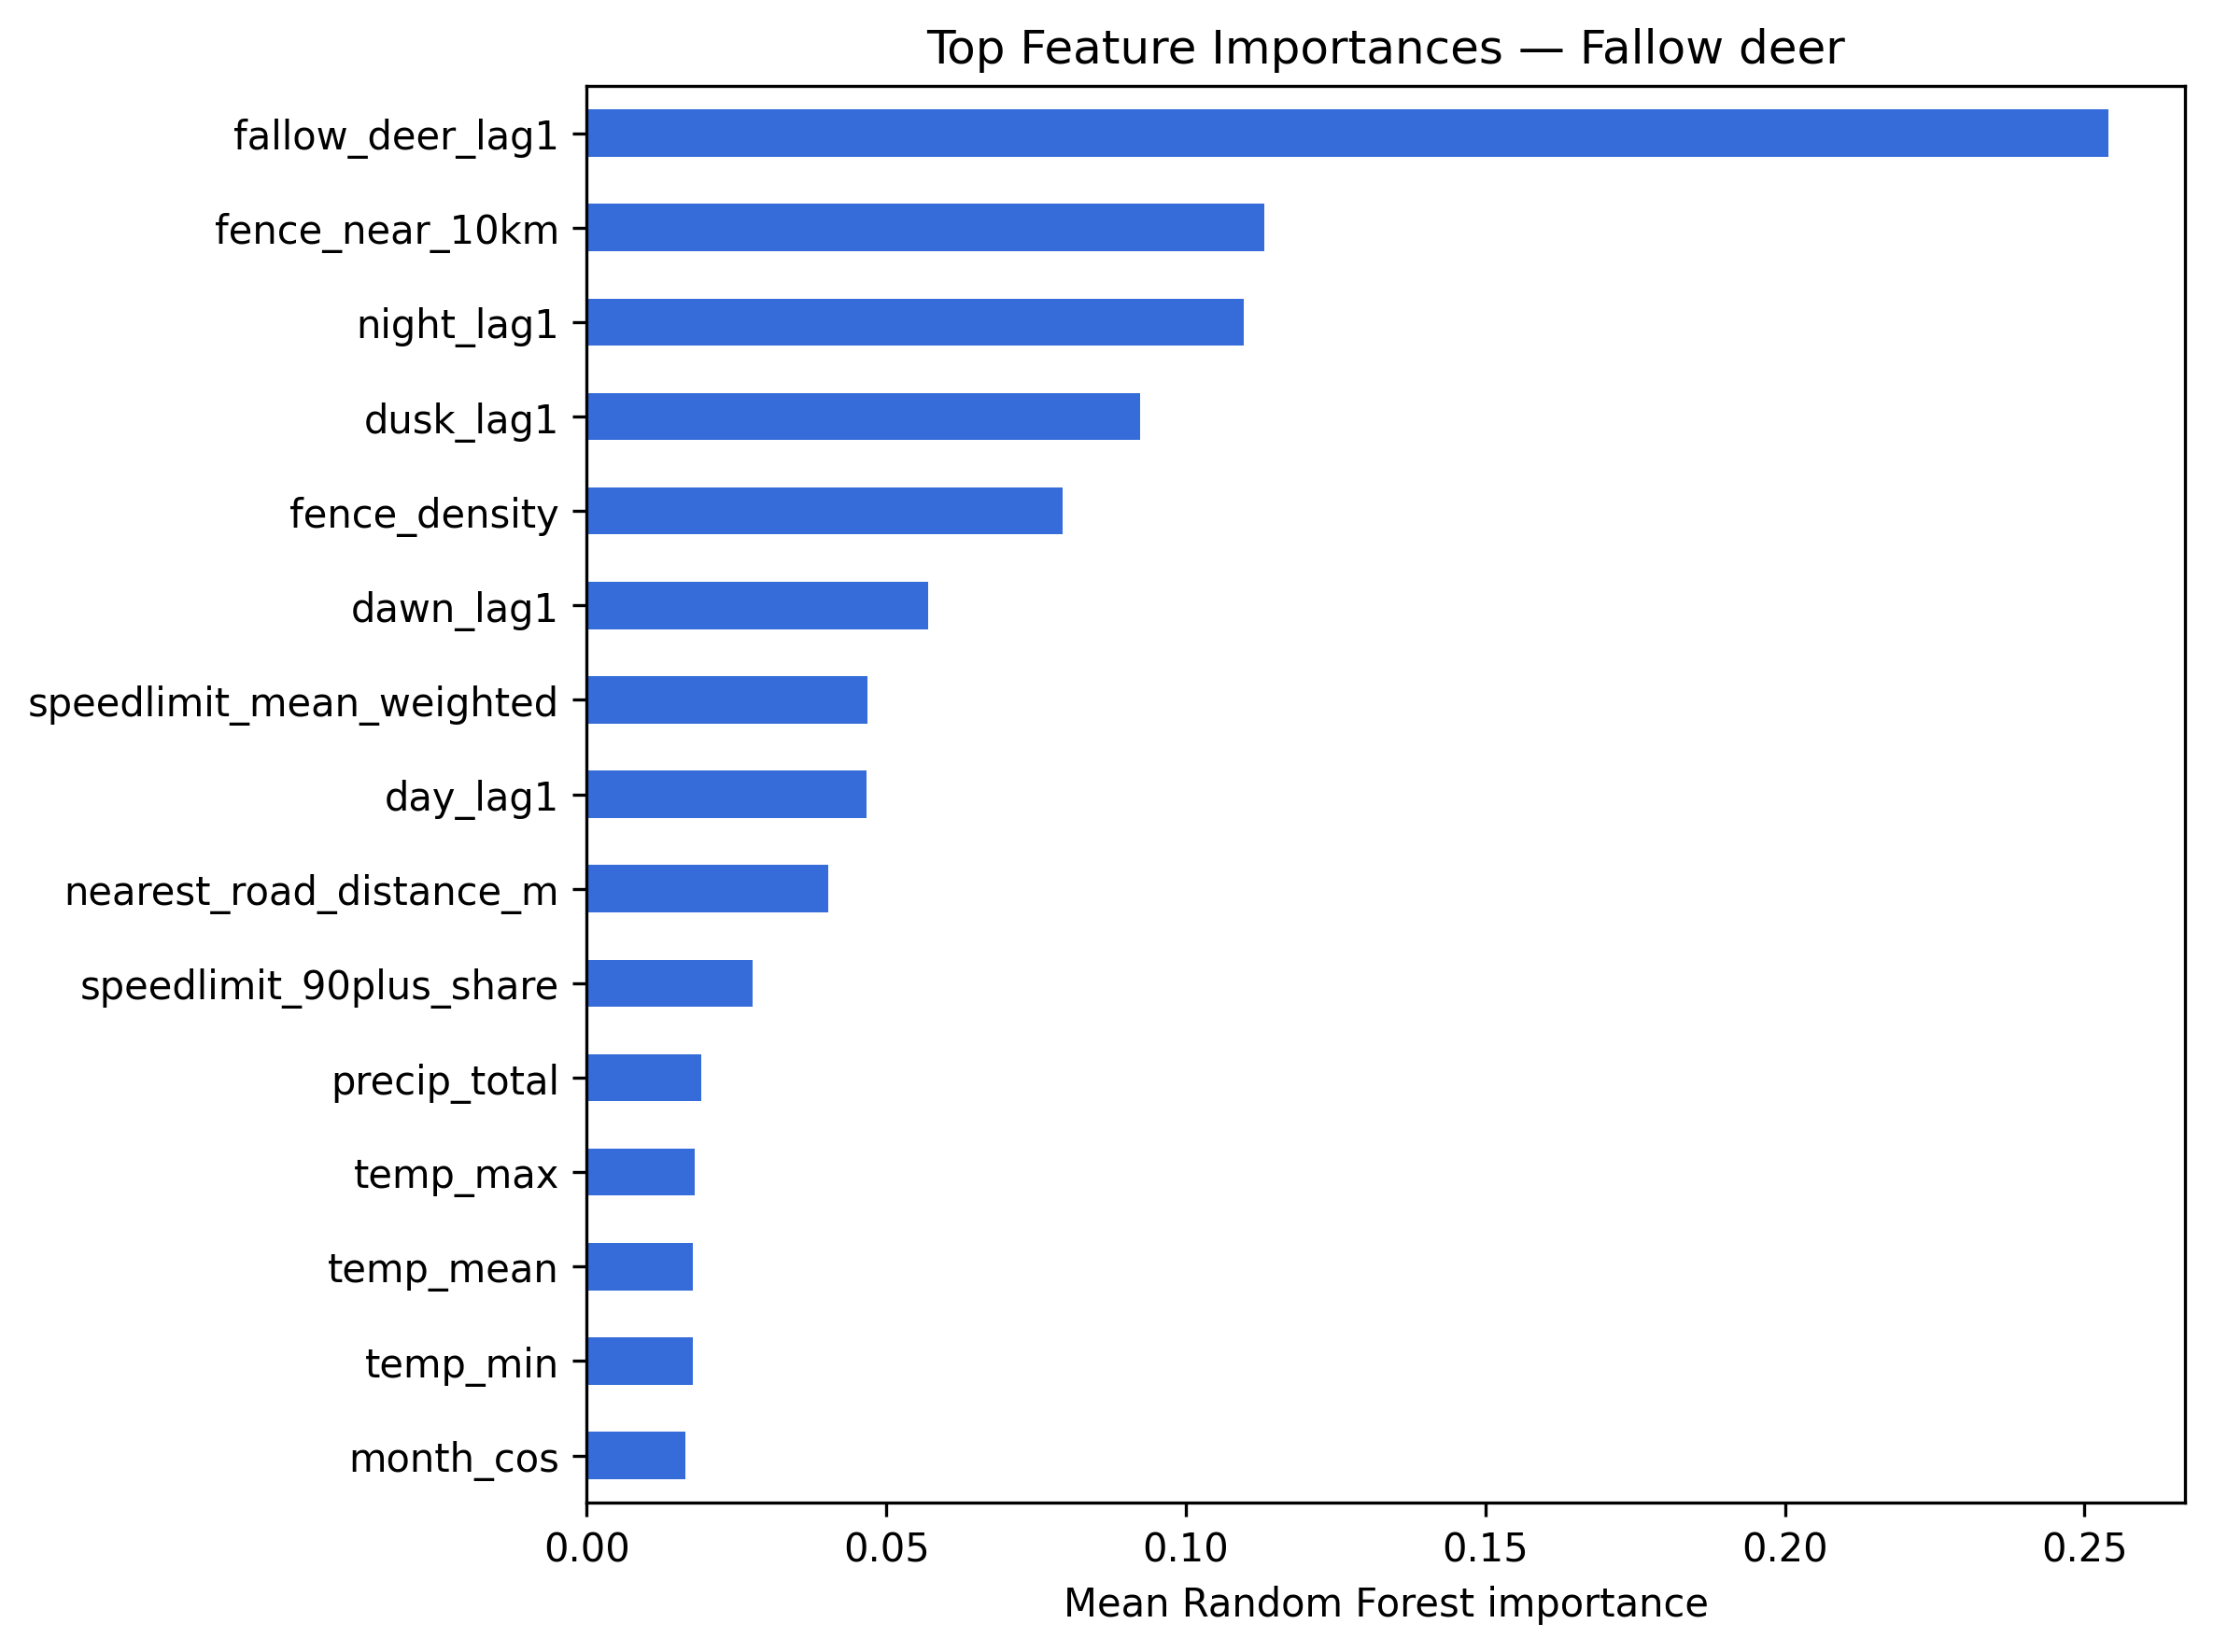

In [18]:
for species_name, importance in species_importances.items():
    plt.figure(figsize=(8, 6))
    importance.head(15).sort_values().plot(kind="barh")
    plt.title(f"Top Feature Importances — {SPECIES_LABELS[species_name]}")
    plt.xlabel("Mean Random Forest importance")
    plt.tight_layout()

    plt.show()

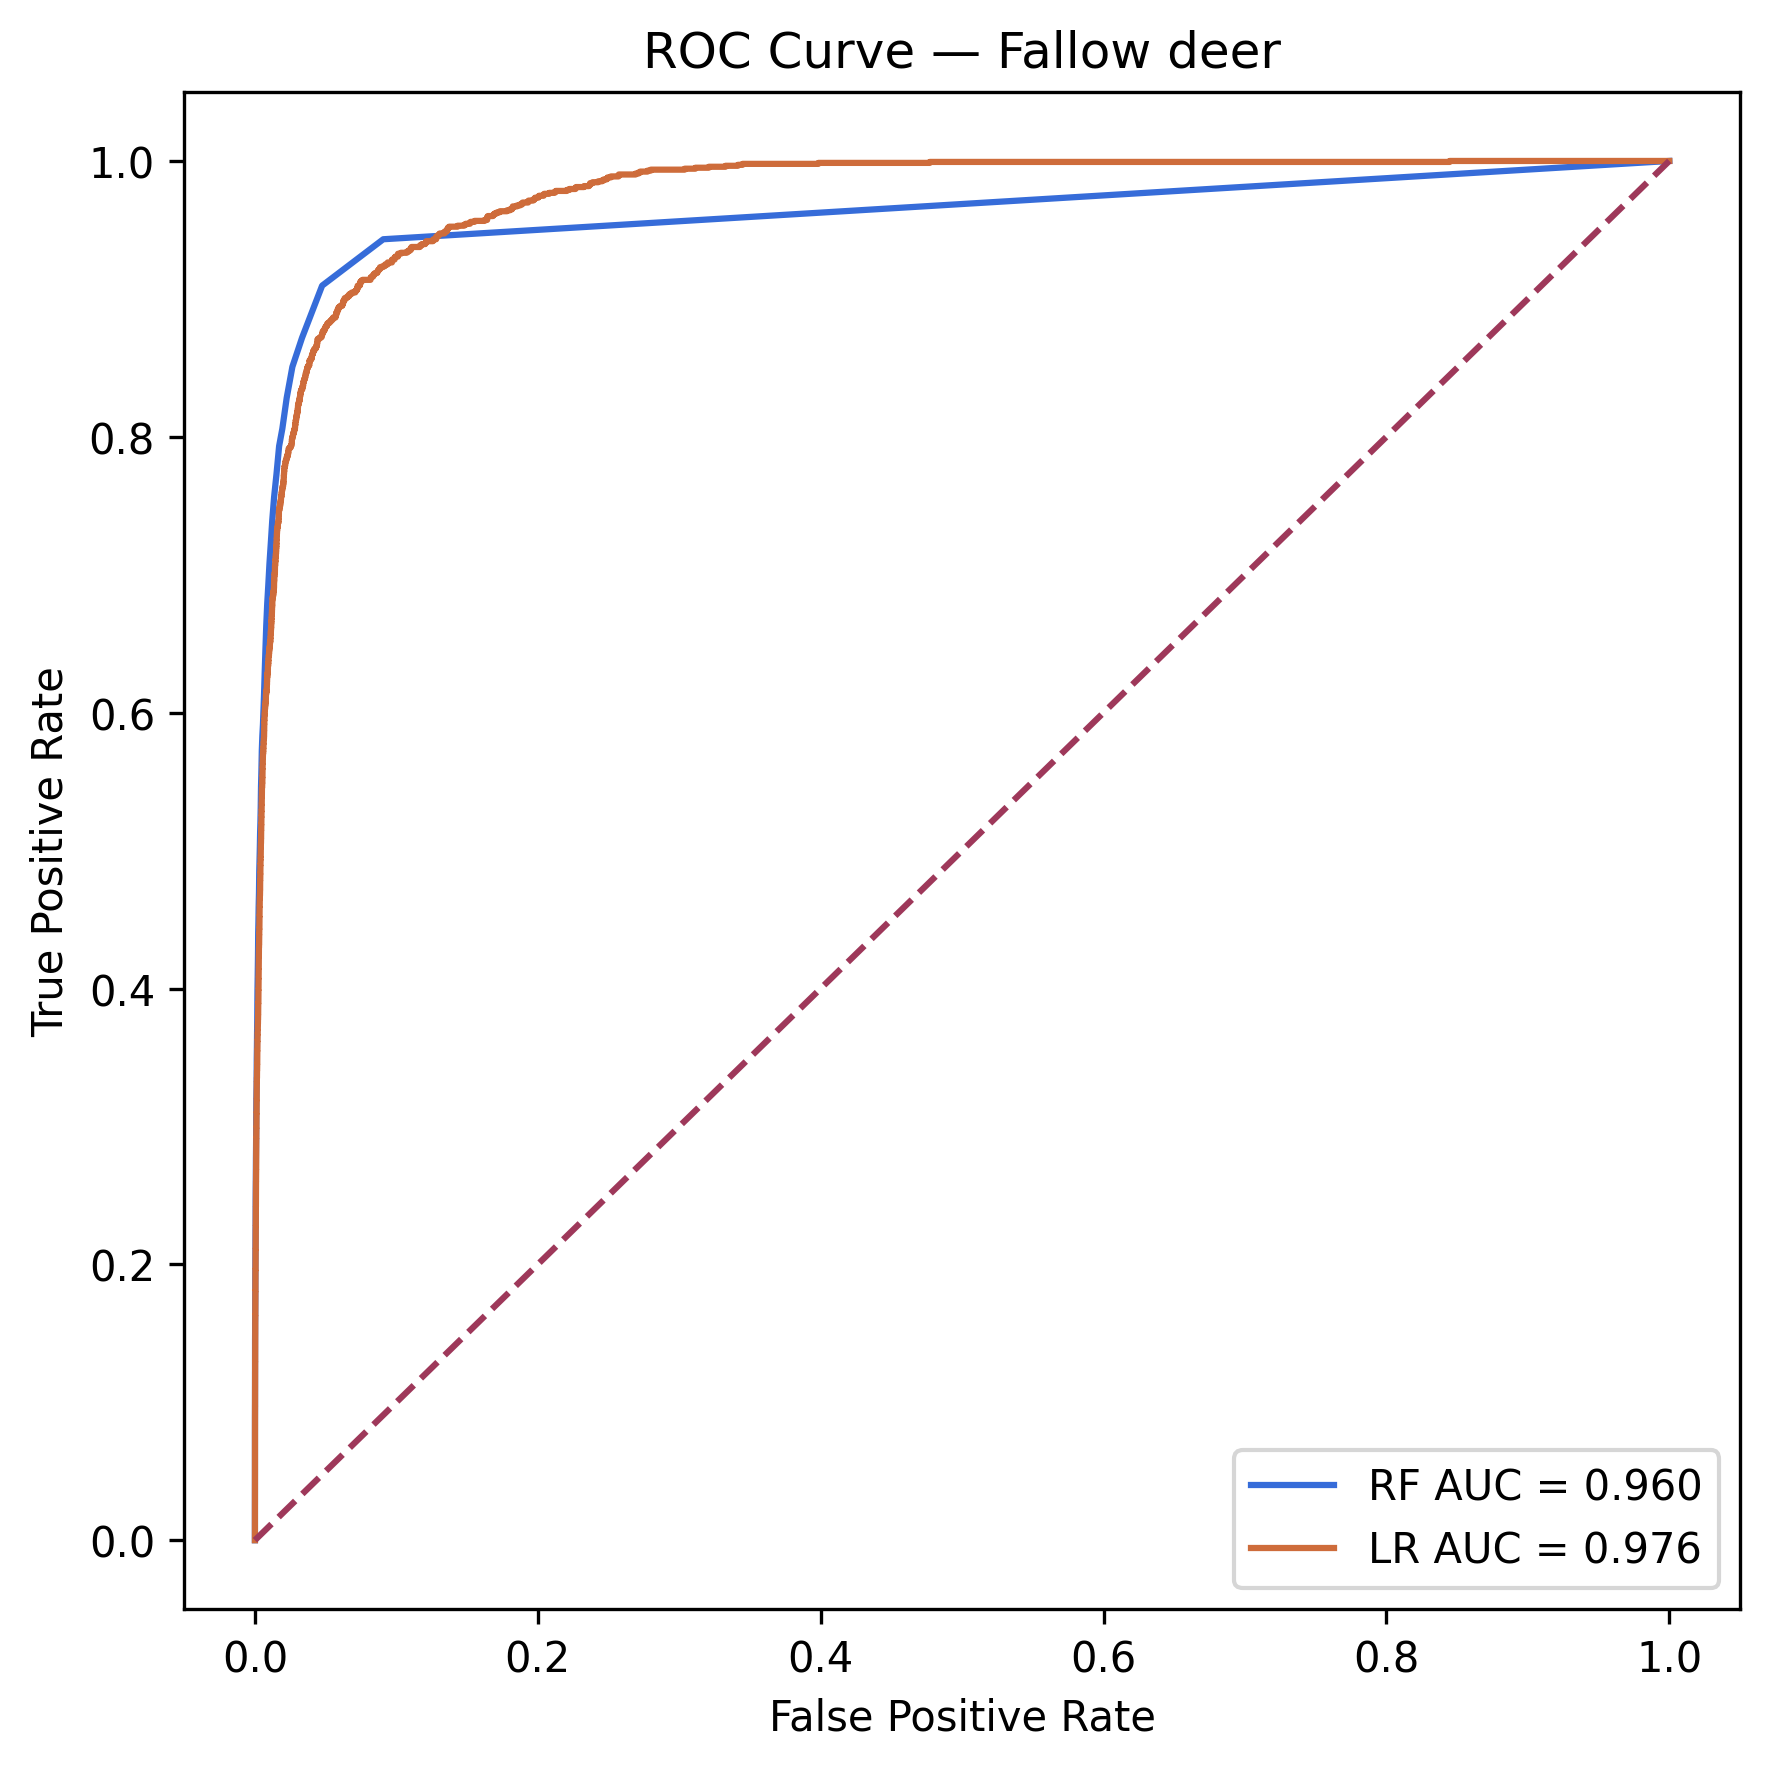

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

for species_name, data in species_results.items():
    oof_labels = data["oof_labels"]
    oof_probs_rf = data["oof_probs_rf"]
    oof_probs_lr = data["oof_probs_lr"]

    fpr_rf, tpr_rf, _ = roc_curve(oof_labels, oof_probs_rf)
    fpr_lr, tpr_lr, _ = roc_curve(oof_labels, oof_probs_lr)

    auc_rf = roc_auc_score(oof_labels, oof_probs_rf)
    auc_lr = roc_auc_score(oof_labels, oof_probs_lr)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr_rf, tpr_rf, label=f"RF AUC = {auc_rf:.3f}")
    plt.plot(fpr_lr, tpr_lr, label=f"LR AUC = {auc_lr:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {SPECIES_LABELS[species_name]}")
    plt.legend()
    plt.tight_layout()

    plt.show()

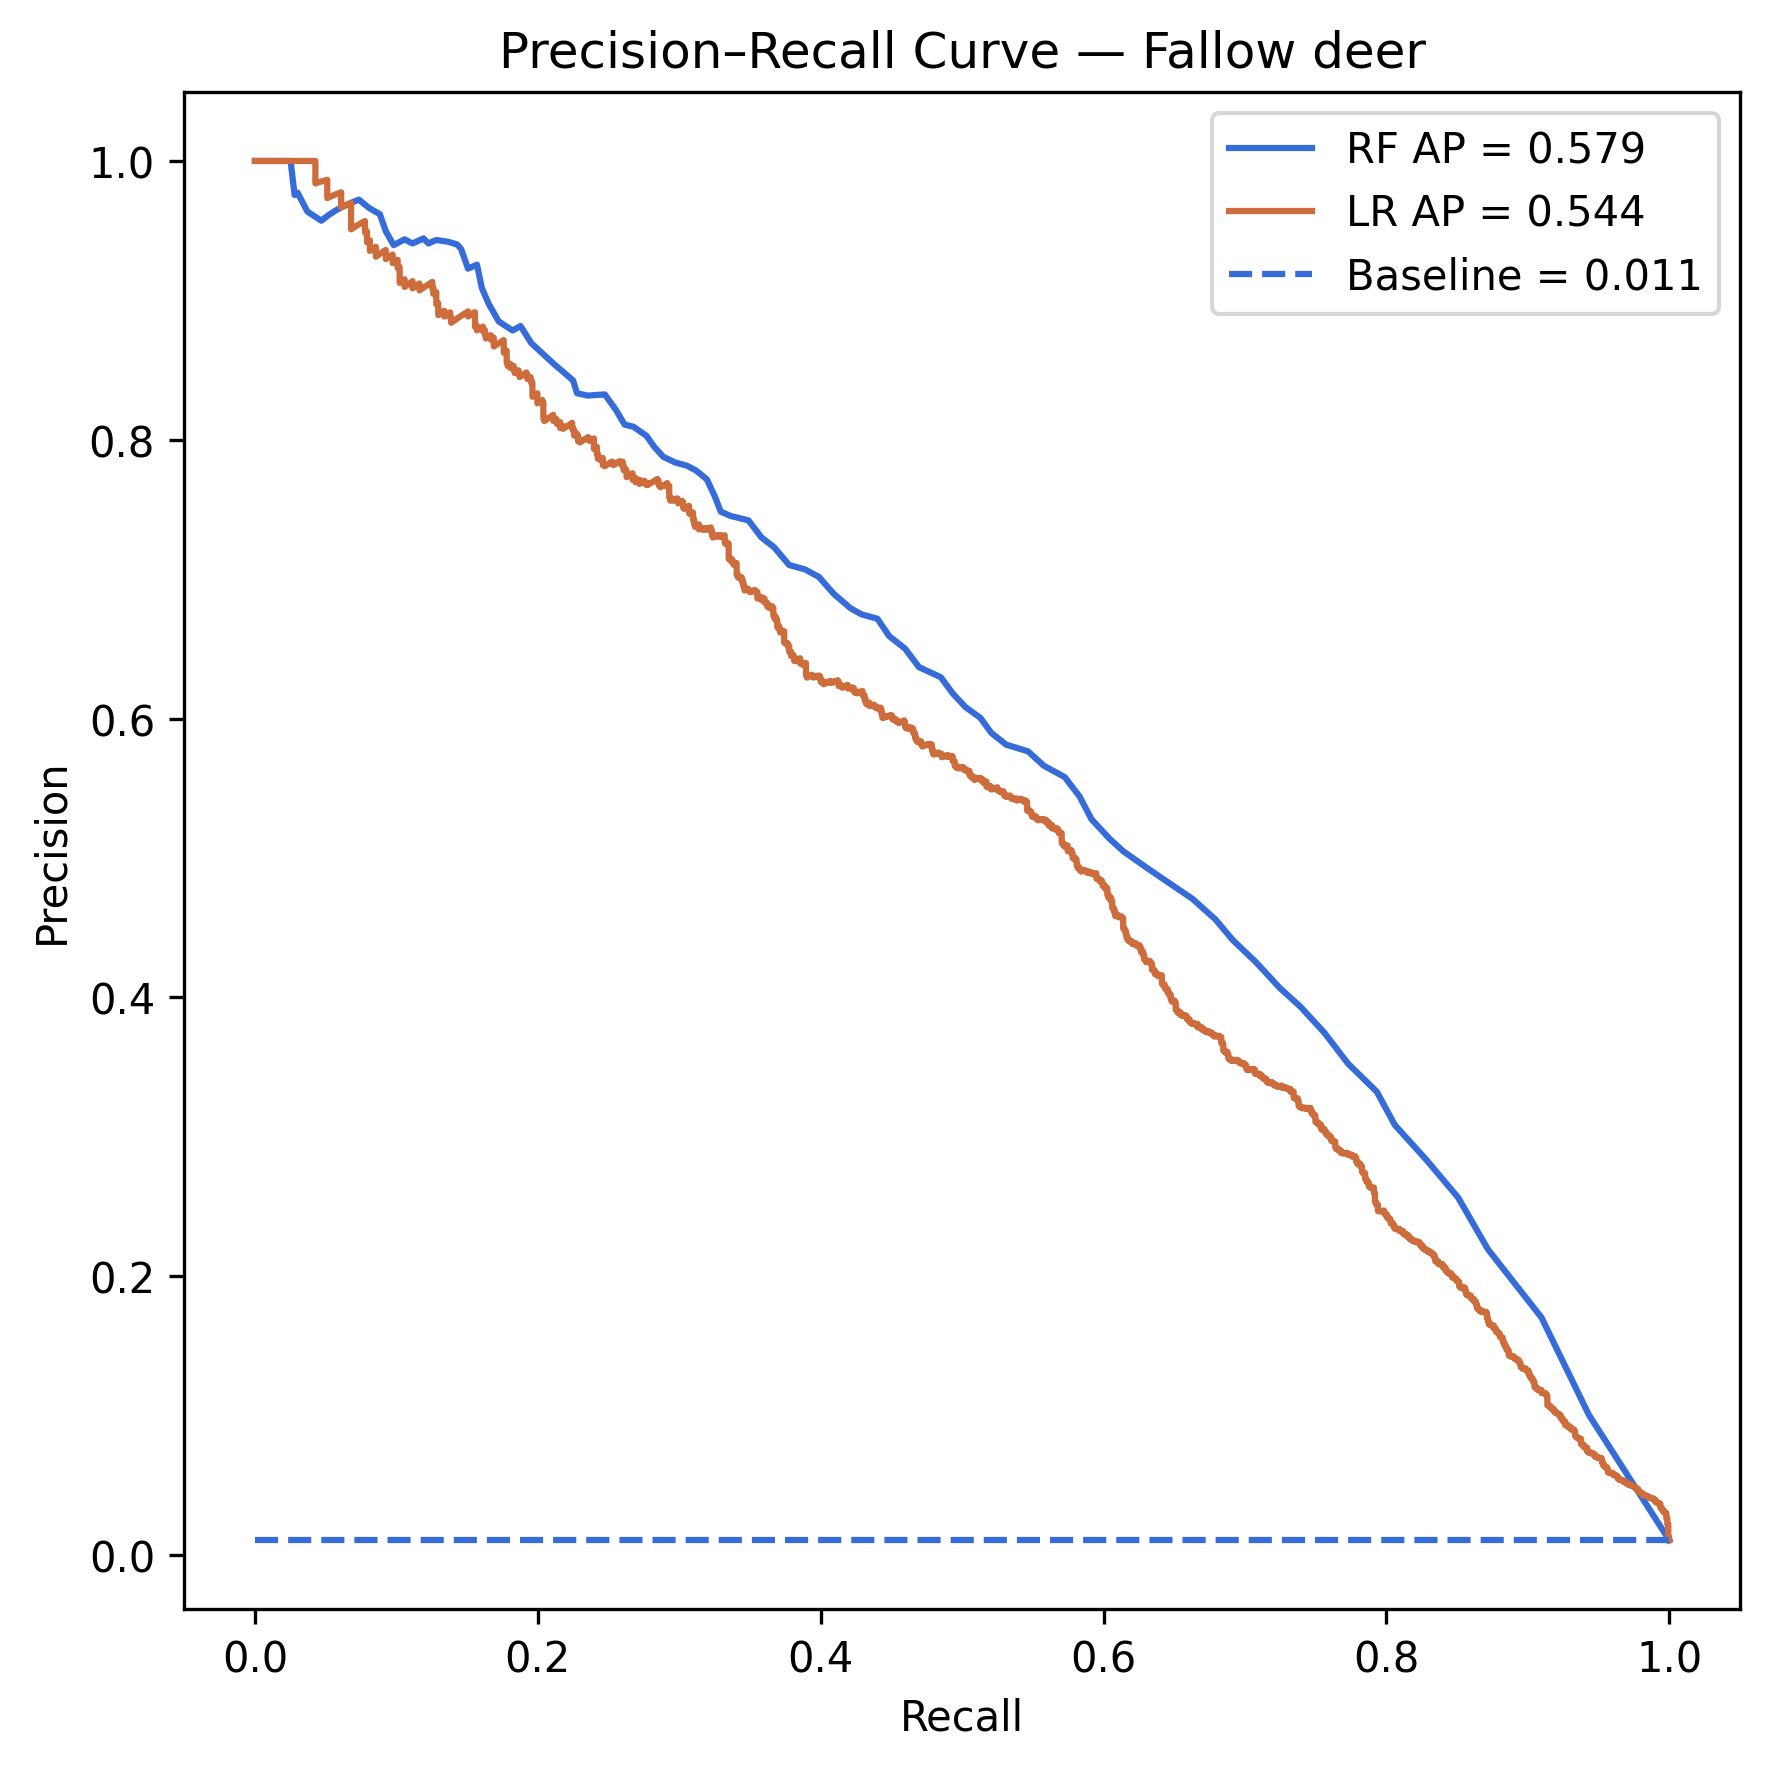

In [20]:
from sklearn.metrics import precision_recall_curve, average_precision_score

for species_name, data in species_results.items():
    oof_labels = data["oof_labels"]
    oof_probs_rf = data["oof_probs_rf"]
    oof_probs_lr = data["oof_probs_lr"]

    precision_rf, recall_rf, _ = precision_recall_curve(oof_labels, oof_probs_rf)
    precision_lr, recall_lr, _ = precision_recall_curve(oof_labels, oof_probs_lr)

    ap_rf = average_precision_score(oof_labels, oof_probs_rf)
    ap_lr = average_precision_score(oof_labels, oof_probs_lr)

    baseline = oof_labels.mean()

    plt.figure(figsize=(6, 6))
    plt.plot(recall_rf, precision_rf, label=f"RF AP = {ap_rf:.3f}")
    plt.plot(recall_lr, precision_lr, label=f"LR AP = {ap_lr:.3f}")
    plt.hlines(baseline, 0, 1, linestyles="--", label=f"Baseline = {baseline:.3f}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve — {SPECIES_LABELS[species_name]}")
    plt.legend()
    plt.tight_layout()

    plt.show()

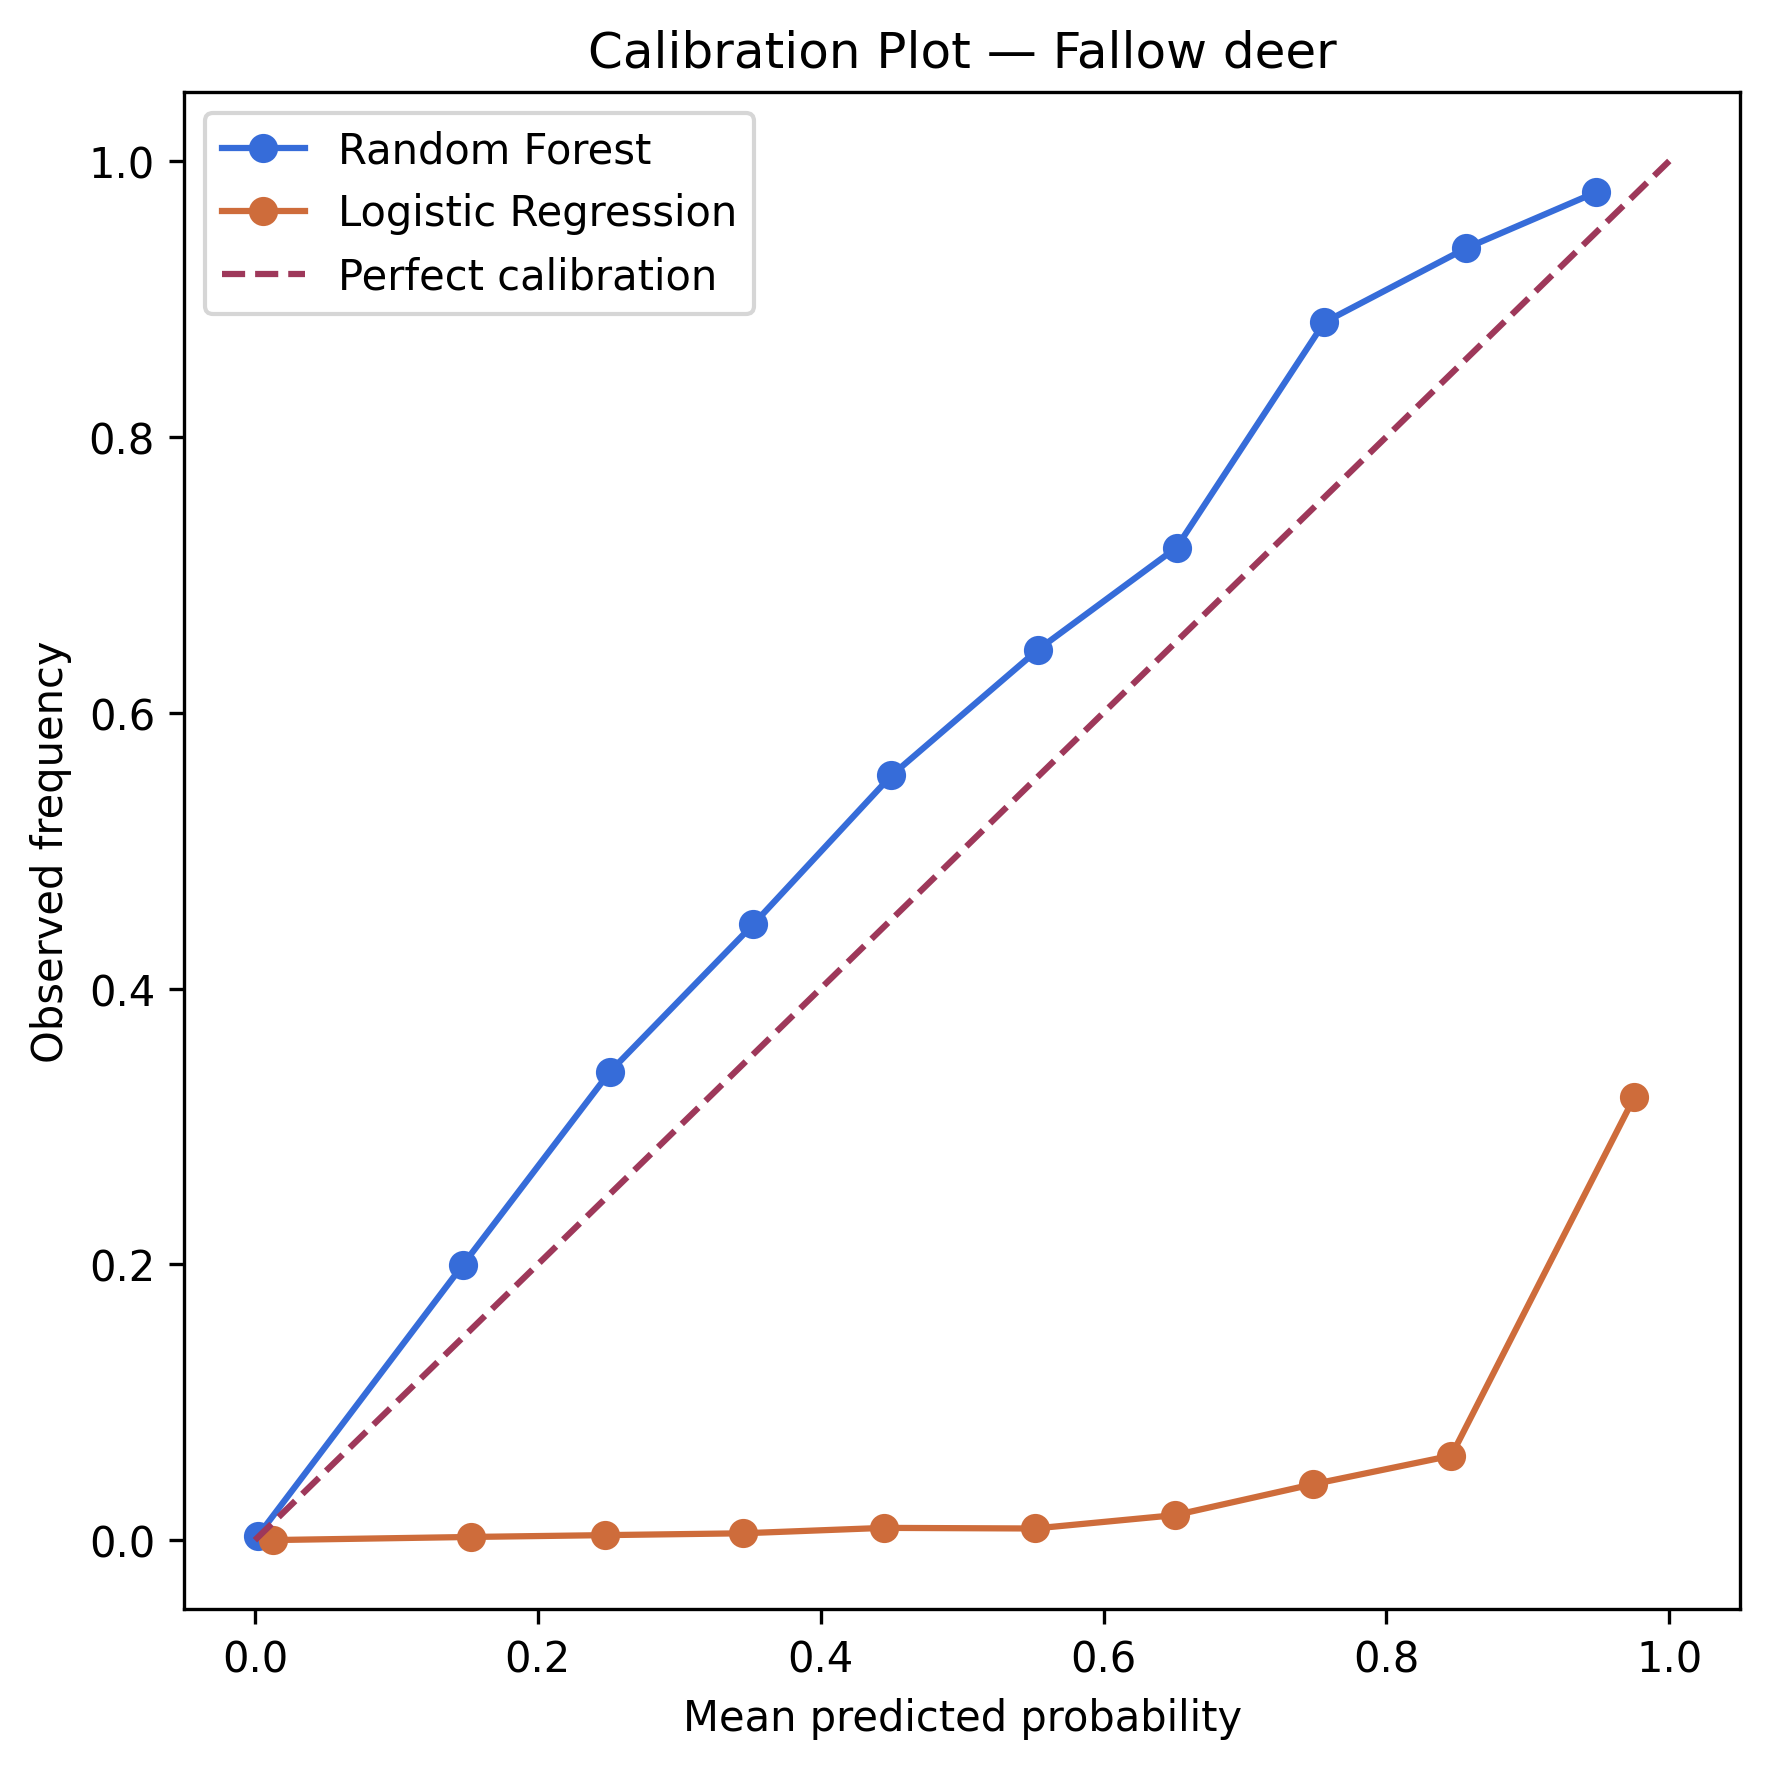

In [21]:
for species_name, data in species_results.items():
    oof_labels = data["oof_labels"]
    oof_probs_rf = data["oof_probs_rf"]
    oof_probs_lr = data["oof_probs_lr"]

    prob_true_rf, prob_pred_rf = calibration_curve(
        oof_labels,
        oof_probs_rf,
        n_bins=10,
        strategy="uniform",
    )

    prob_true_lr, prob_pred_lr = calibration_curve(
        oof_labels,
        oof_probs_lr,
        n_bins=10,
        strategy="uniform",
    )

    plt.figure(figsize=(6, 6))
    plt.plot(prob_pred_rf, prob_true_rf, marker="o", label="Random Forest")
    plt.plot(prob_pred_lr, prob_true_lr, marker="o", label="Logistic Regression")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed frequency")
    plt.title(f"Calibration Plot — {SPECIES_LABELS[species_name]}")
    plt.legend()
    plt.tight_layout()

    plt.show()

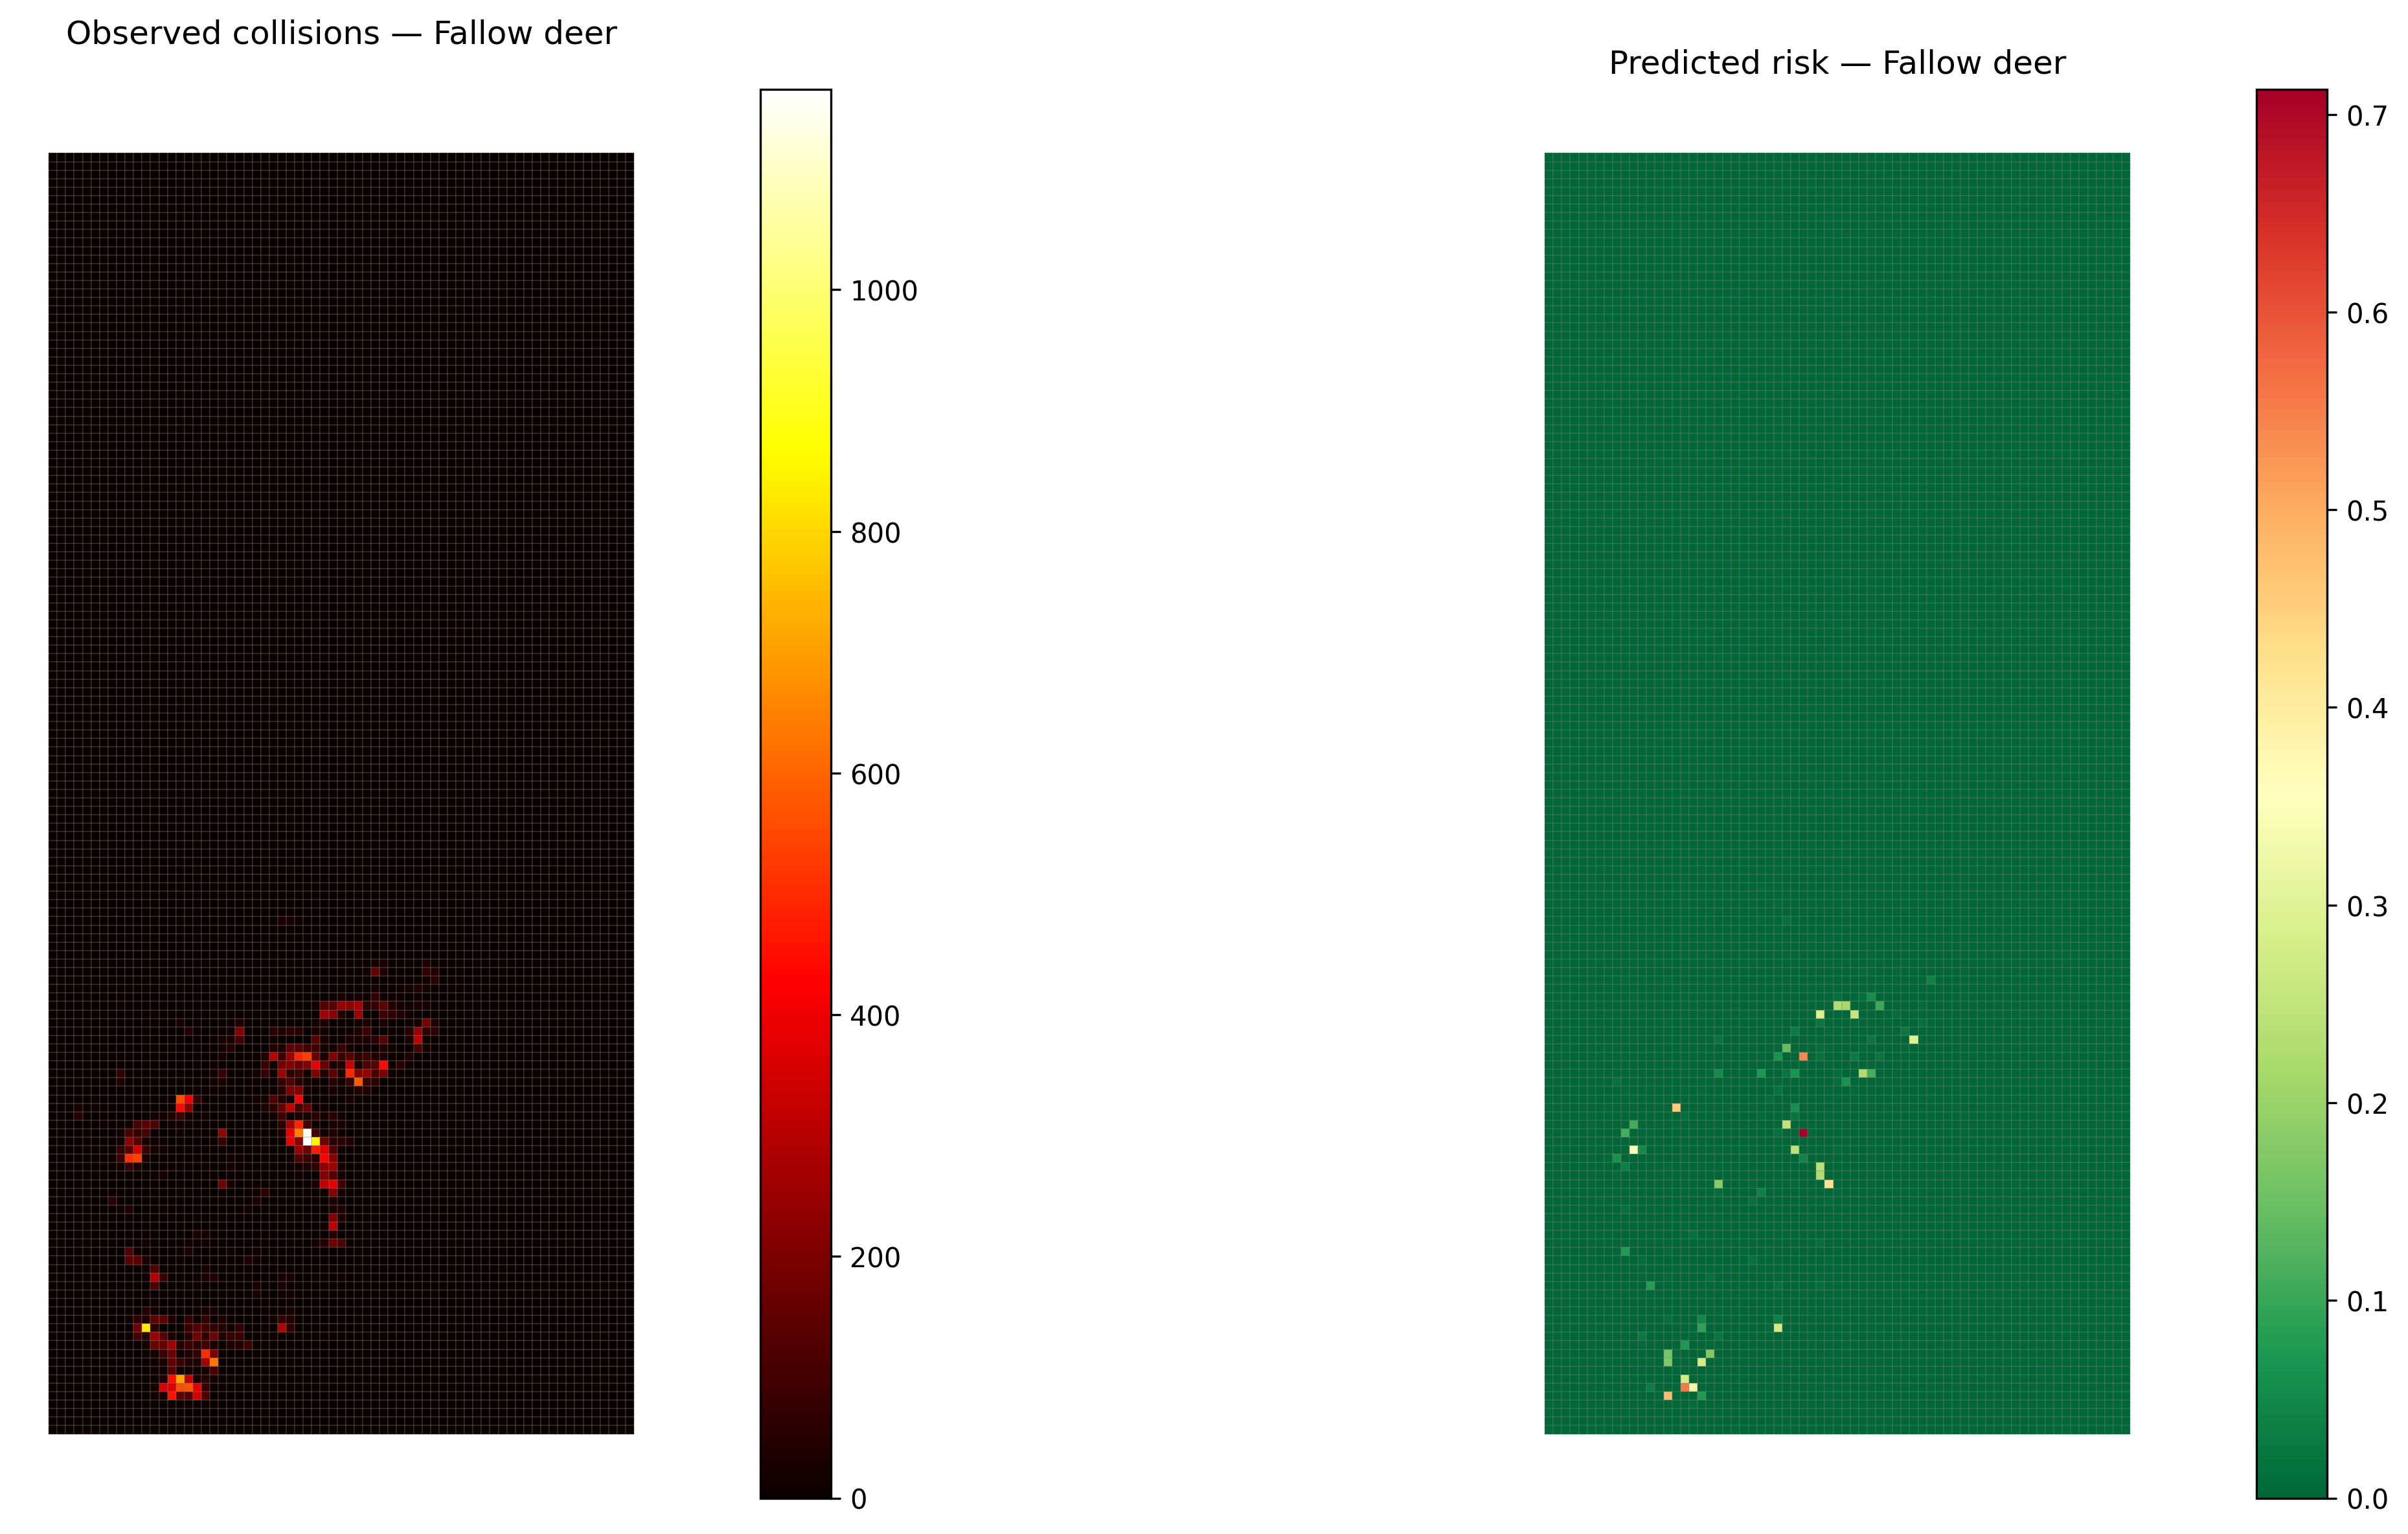

In [22]:
for species_name, data in species_results.items():
    species_df_clean = data["df"]
    species_features = data["features"]

    rf_final = RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )

    rf_final.fit(
        species_df_clean[species_features],
        species_df_clean["risk"],
    )

    species_df_clean = species_df_clean.copy()
    species_df_clean["risk_prob"] = rf_final.predict_proba(
        species_df_clean[species_features]
    )[:, 1]

    cell_risk = (
        species_df_clean
        .groupby("cell_id")["risk_prob"]
        .mean()
        .reset_index()
    )

    grid_risk = grid.merge(cell_risk, on="cell_id", how="left")
    grid_risk["risk_prob"] = grid_risk["risk_prob"].fillna(0)

    species_joined = joined.copy()
    species_joined["species_clean"] = (
        species_joined["species"]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace(SPECIES_MAP)
    )

    species_joined = species_joined[
        species_joined["species_clean"] == species_name
        ].copy()

    cell_totals = (
        species_joined
        .groupby("cell_id")
        .size()
        .reset_index(name="collision_count")
    )

    grid_heatmap = grid.merge(cell_totals, on="cell_id", how="left")
    grid_heatmap["collision_count"] = grid_heatmap["collision_count"].fillna(0)

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    grid_heatmap.plot(
        column="collision_count",
        cmap="hot",
        linewidth=0.1,
        edgecolor="grey",
        legend=True,
        ax=axes[0],
    )

    axes[0].set_title(f"Observed collisions — {SPECIES_LABELS[species_name]}")
    axes[0].set_axis_off()

    grid_risk.plot(
        column="risk_prob",
        cmap="RdYlGn_r",
        linewidth=0.1,
        edgecolor="grey",
        legend=True,
        ax=axes[1],
    )

    axes[1].set_title(f"Predicted risk — {SPECIES_LABELS[species_name]}")
    axes[1].set_axis_off()

    plt.tight_layout()

    plt.show()

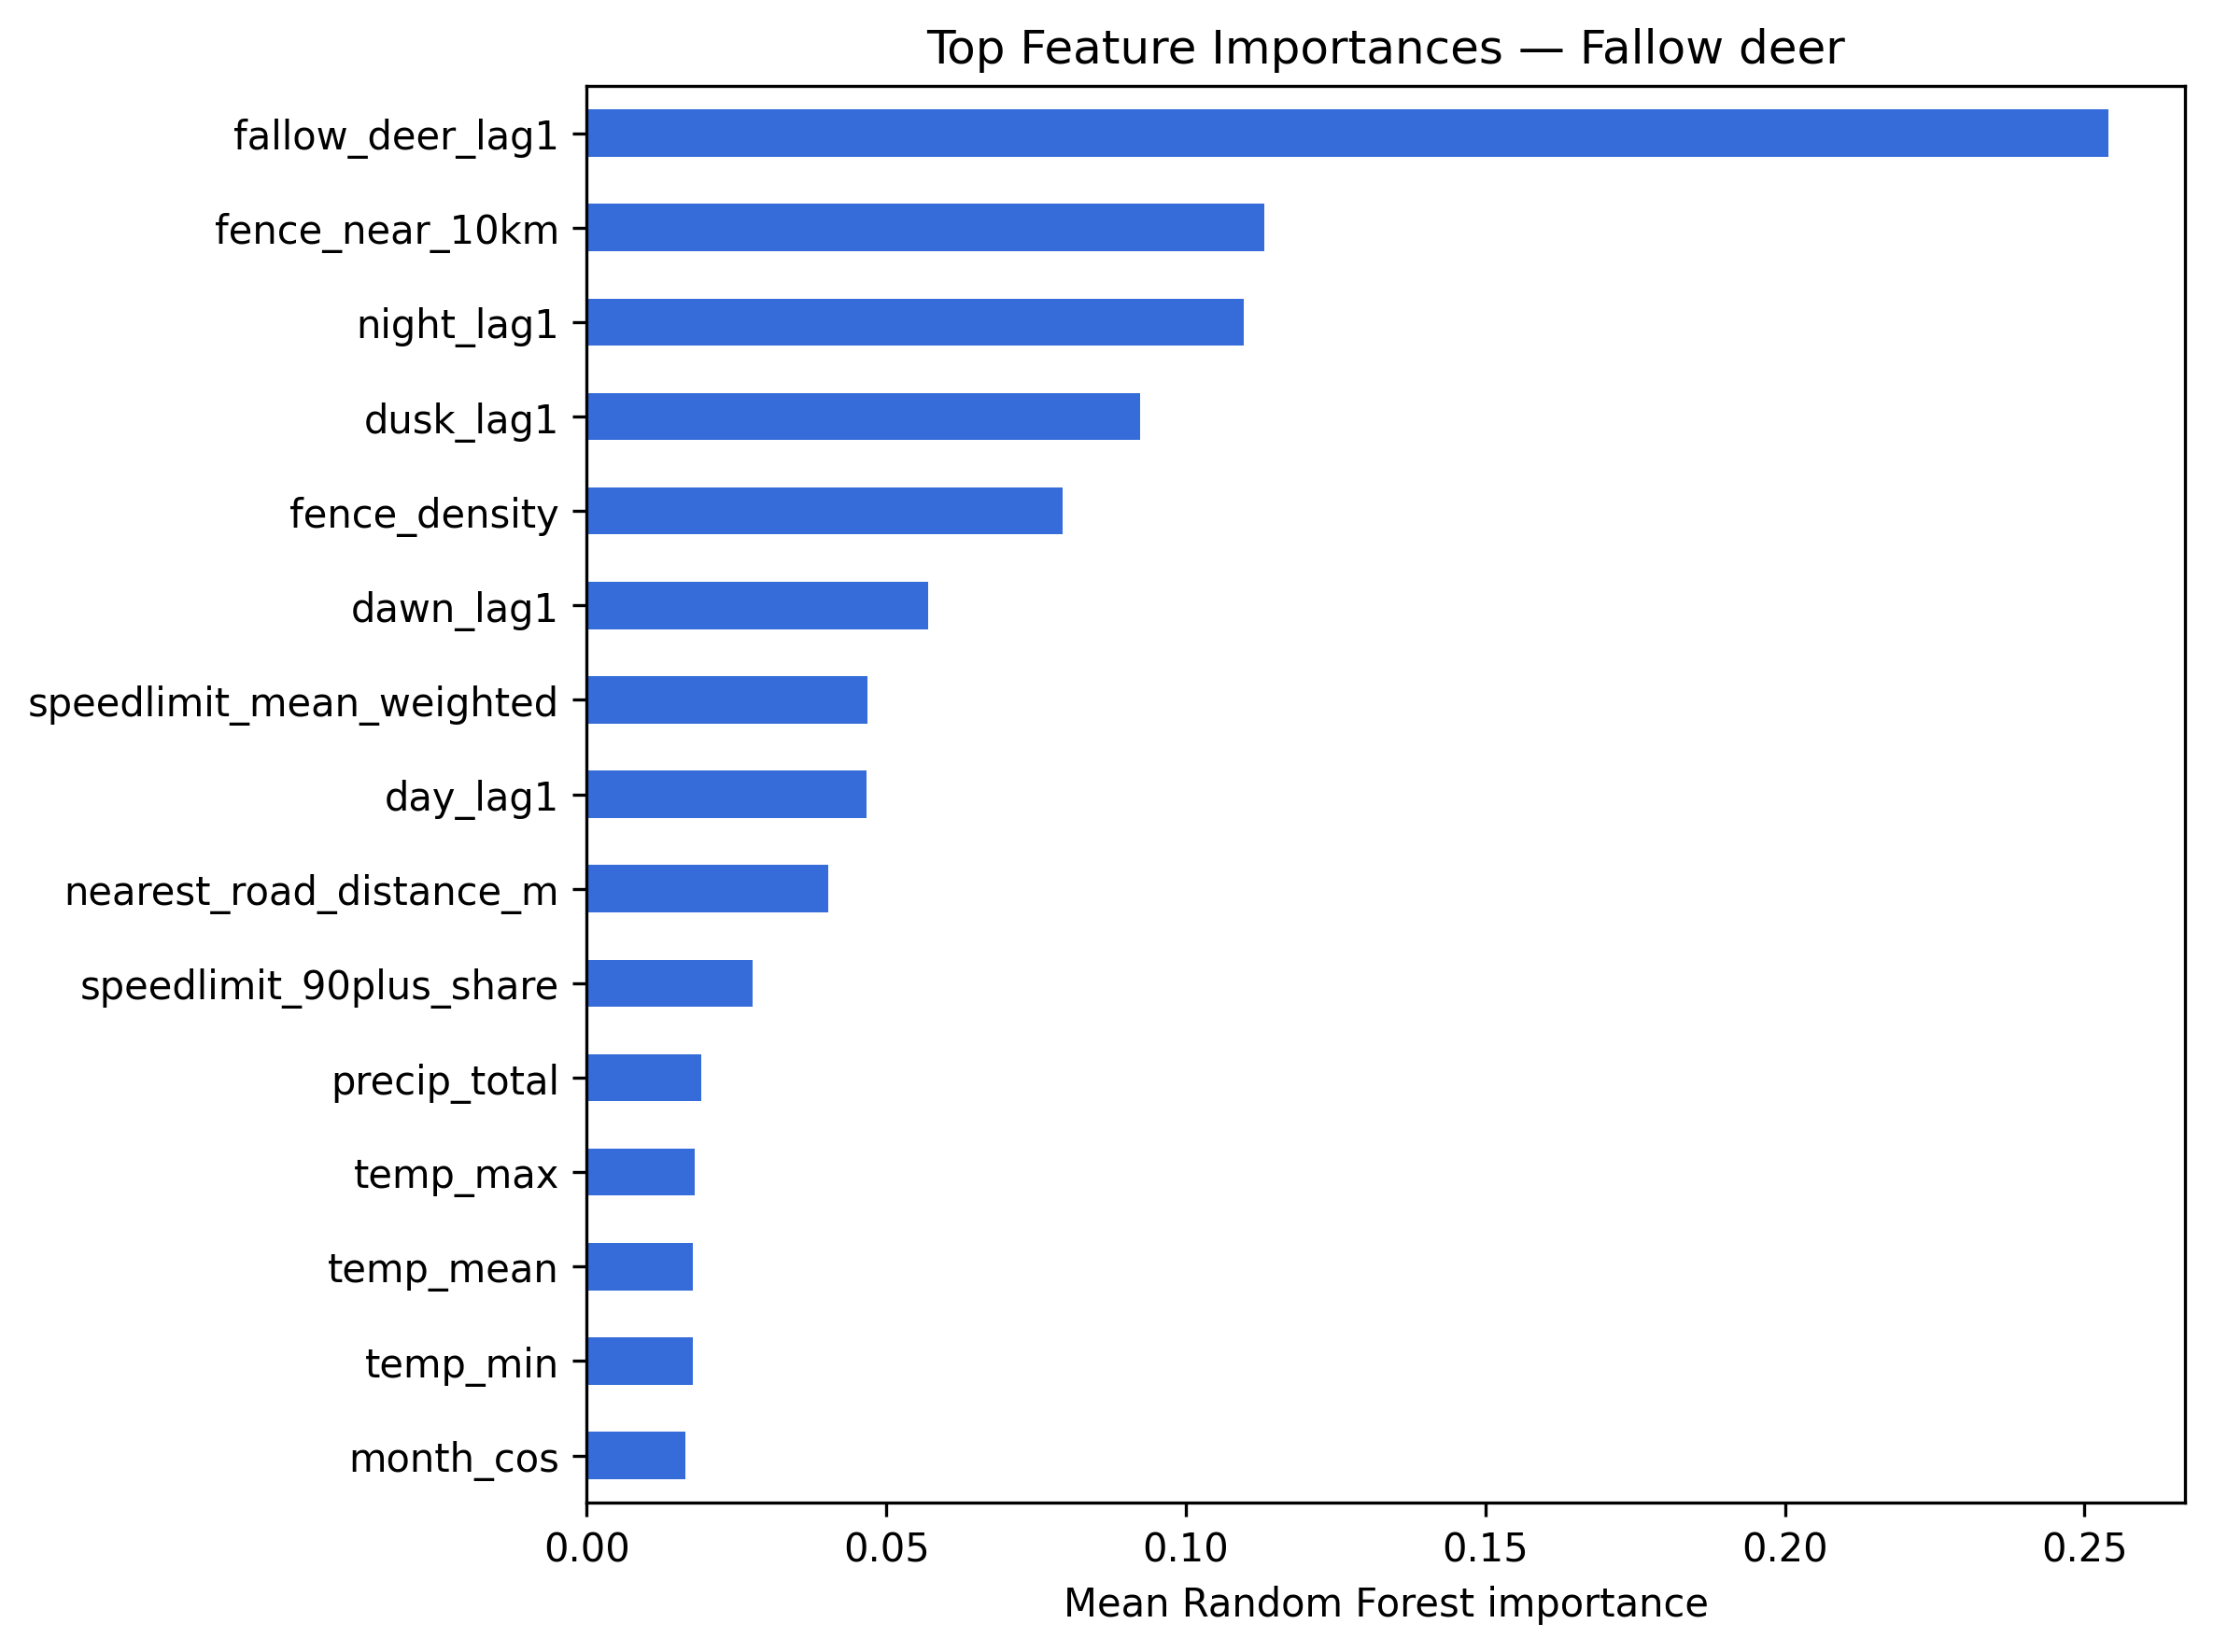

In [23]:
for species_name, importance in species_importances.items():
    plt.figure(figsize=(8, 6))
    importance.head(15).sort_values().plot(kind="barh")
    plt.title(f"Top Feature Importances — {SPECIES_LABELS[species_name]}")
    plt.xlabel("Mean Random Forest importance")
    plt.tight_layout()

    plt.show()